<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day13_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.feature_selection import VarianceThreshold # remove feature with vey low
import pandas as pd

'''
Sample data
feature1 has no variation so its useless for learning
feature2 and feature3 vary
'''
X = pd.DataFrame({
    "feature1": [1,1,1,1,1], #low variance
    "feature2": [1,2,3,4,5],
    "feature3": [10,20,30,40,50]
    })
selector = VarianceThreshold(threshold=0.1) #Any feature with variance <=0.1 will be remove
X_selected = selector.fit_transform(X)

print(X_selected)

'''
Learns varience fron data(fit)
remove low -variance feature(transform)
Result:
Feature1 is removed because it carries no information.'''



[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]
 [ 5 50]]


'\nLearns varience fron data(fit)\nremove low -variance feature(transform)\nResult:\nFeature1 is removed because it carries no information.'

Remove feature that do not change much


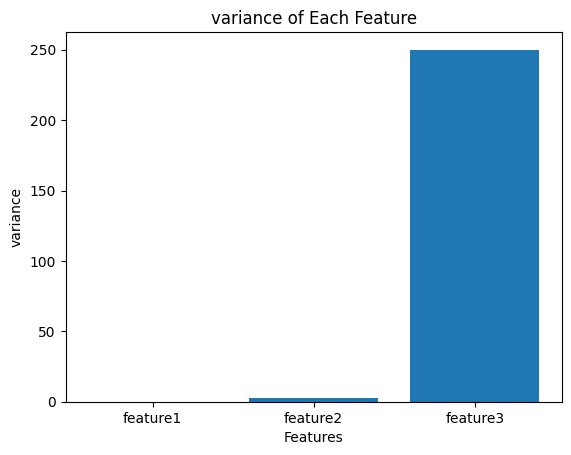

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

#SAmple data
X = pd.DataFrame({
    "feature1": [1,1,1,1,1], #low variance
    "feature2": [1,2,3,4,5],
    "feature3": [10,20,30,40,50]

})

#calculate variance manually for visualization
variance = X.var()

#plot variance
plt.figure()
plt.bar(variance.index,variance.values)
plt.xlabel("Features")
plt.ylabel("variance")
plt.title("variance of Each Feature")
plt.show()

In [3]:
from sklearn.feature_selection import VarianceThreshold # remove feature with vey low
import pandas as pd

'''
Sample data
feature1 has no variation so its useless for learning
feature2 and feature3 vary
'''
X = pd.DataFrame({
    "feature1": [1,1,1,1,1], #low variance
    "feature2": [1,2,3,4,5],
    "feature3": [25,26,31,41,55]
    })
selector = VarianceThreshold(threshold=0.2) #Any feature with variance <=0.1 will be remove
X_selected = selector.fit_transform(X)

print(X_selected)

'''
Learns varience fron data(fit)
remove low -variance feature(transform)
Result:
Feature1 is removed because it carries no information.'''



[[ 1 25]
 [ 2 26]
 [ 3 31]
 [ 4 41]
 [ 5 55]]


'\nLearns varience fron data(fit)\nremove low -variance feature(transform)\nResult:\nFeature1 is removed because it carries no information.'

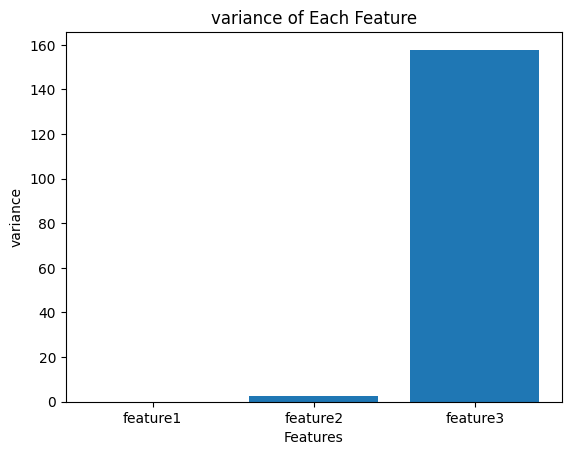

In [4]:

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

#SAmple data
X = pd.DataFrame({
    "feature1": [1,1,1,1,1], #low variance
    "feature2": [1,2,3,4,5],
    "feature3": [25,26,31,41,55]

})

#calculate variance manually for visualization
variance = X.var()

#plot variance
plt.figure()
plt.bar(variance.index,variance.values)
plt.xlabel("Features")
plt.ylabel("variance")
plt.title("variance of Each Feature")
plt.show()

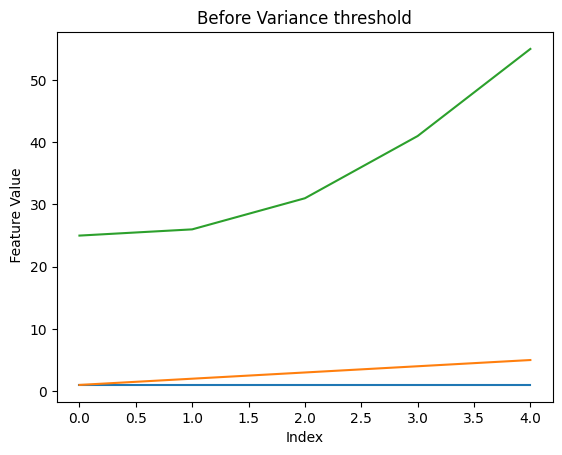

In [5]:
plt.figure()
plt.plot(X)
plt.title("Before Variance threshold")
plt.xlabel("Index")
plt.ylabel(" Feature Value")
plt.show()

Correlation -BAsed Feature Selection



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Dataset

data = {
    "Engine_size":[1.2,1.5,2.0,2.2,3.0,3.5,4.0,1.8,2.5,3.2],
    "Horsepower": [90,110,150,170,220,250,300,140,200,240],
    "Weight": [900,1000,1300,1500,2000,2200,1250,1700,1950,2890],
    "Fuel_Consumption":[15,14,12,11,9,8,7,13,10,8.5],
    "Mileage":[20,19,16,15,12,11,10,17,13,11]
}
X = pd.DataFrame(data)

print("Original Dataset Shape:",X.shape)
print(X.head())

#correlation matrix
corr_matrix = X.corr().abs()

#Kepp only upper Triangle

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=2).astype(bool))

#find highly Correlated Features
to_drop =[col for col in upper_triangle.columns if any (upper_triangle [col]> 0.9)]
print("\n Highly correlated feature to drop:",to_drop)
  #drop redudent Features
X_reduced = X.drop(columns=to_drop)
print("\n Reduced Dtaset shape:",X_reduced.shape)
print(X_reduced.head())



Original Dataset Shape: (10, 5)
   Engine_size  Horsepower  Weight  Fuel_Consumption  Mileage
0          1.2          90     900              15.0       20
1          1.5         110    1000              14.0       19
2          2.0         150    1300              12.0       16
3          2.2         170    1500              11.0       15
4          3.0         220    2000               9.0       12

 Highly correlated feature to drop: ['Fuel_Consumption', 'Mileage']

 Reduced Dtaset shape: (10, 3)
   Engine_size  Horsepower  Weight
0          1.2          90     900
1          1.5         110    1000
2          2.0         150    1300
3          2.2         170    1500
4          3.0         220    2000


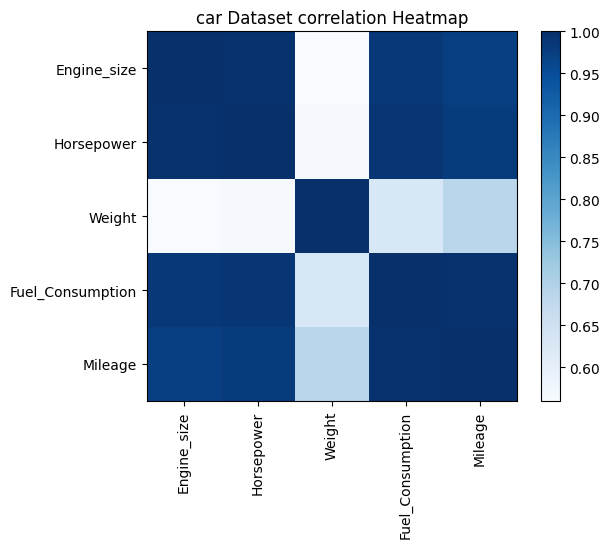

In [7]:
#Visualization -correlation heatmap

plt.figure()
plt.imshow(corr_matrix,cmap="Blues") #change color here
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)),corr_matrix.columns,rotation=90)
plt.yticks(range(len(corr_matrix.columns)),corr_matrix.columns)
plt.title("car Dataset correlation Heatmap")
plt.show()